# Three-Stage Sigma Fitting with Compact Sequences

Fits the three-regime noise parameters **independently**, using compact
multi-ISI sequences (via `ISISequence` + `StimulusManager`) for the
sigma1 and sigma2 stages instead of per-ISI toy experiments.

| Stage | Parameter | Method | ISIs |
|-------|-----------|--------|------|
| A | `sigma0` | ISI-0 toy experiments | [0] |
| B | `sigma1` | Compact multi-ISI sequences | [1, 2, 4] |
| C | `sigma2` | Compact multi-ISI sequences | [8, 16, 32, 64] |

Each stage does a **1-D grid search** with iterative refinement via
`fit_sigma_1d`, then the final fitted parameters are evaluated on
**all** real participant sequences.

In [1]:
import sys, os, yaml, torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from scipy.spatial.distance import pdist

sys.path.append('/om2/user/jmhicks/projects/TextureStreaming/code/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/utls/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/src/model/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/')

from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params, statistics_set, texture_dataset
from texture_prior.utils import path

from utls.plotting import ensure_dir
from utls.loading import (
    load_results_with_exclusion_2,
    move_sequences_to_used,
    load_results_with_exclusion_no_dropping,
)
from utls.runners_v2 import run_experiment_scores, make_noise_schedule
from utls.runners_utils import *
from utls.analysis_helpers import auroc_to_dprime
from utls.io_utils import (
    make_model_save_dir,
    save_all_figures,
    save_single_figure,
    save_runs_summary,
)
from encoders import *

from utls.toy_experiments import (
    make_toy_experiment_list,
    make_compact_multi_isi_sequences,
    infer_trial_isis,
)
from utls.sigma_fitting import (
    log_mid,
    fit_sigma_1d,
    plot_sigma_fit,
)

## 1. Load config & data

In [2]:
def load_config(cfg_path):
    cfg_path = Path(cfg_path)
    if not cfg_path.exists():
        raise FileNotFoundError(cfg_path)
    with open(cfg_path) as f:
        return yaml.safe_load(f), cfg_path


CONFIG_PATH = (
    "/om2/user/bjmedina/auditory-memory/memory/"
    "model_yamls/three-regime/resnet50/time_avg/run_000005.yaml"
)

model_cfg, model_cfg_path = load_config(CONFIG_PATH)
print(model_cfg)

{'results_root': '/om2/user/bjmedina/auditory-memory/memory', 'tag': 'slurm', 'experiment': {'is_multi': True, 'n_seqs': 36, 'n_samples': 50, 'which_task': 0}, 'metric': 'cosine', 'noise_model': {'name': 'three-regime', 'sigma0_min': 3.0, 'sigma0_max': 0.5, 'sigma1_min': 0.1, 'sigma1_max': 0.6, 'sigma2_min': 0.0005, 'sigma2_max': 0.1, 't_step': 5}, 'run_id': 'run_000005', 'representation': {'type': 'resnet50', 'layer': 'layer4', 'time_avg': True}}


In [3]:
# ---- experiment ----
exp_cfg = model_cfg["experiment"]
which_task = exp_cfg["which_task"]
is_multi = exp_cfg["is_multi"]
which_isi = exp_cfg.get("which_isi", None)

isis = [0, 1, 2, 4, 8, 16, 32, 64] if is_multi else [0, which_isi]

# ---- metric ----
metric = model_cfg["metric"]

# ---- noise model ----
noise_cfg = model_cfg["noise_model"]
noise_mode = noise_cfg["name"]
t_step = noise_cfg["t_step"]

# ---- representation ----
repr_cfg = model_cfg["representation"]
time_avg = repr_cfg["time_avg"]
encoder_type = repr_cfg["type"]
layer = repr_cfg.get("layer", None)
pc_dims = repr_cfg.get("pc_dims", None)

# ---- load human data ----
exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = (
    load_experiment_data(which_task, which_isi, is_multi, old=False)
)

human_curve = compute_human_curve(human_runs, is_multi, which_isi)
print("ISIs:", isis)
print("Human d' curve:", human_curve)
print(f"Total real sequences: {len(exp_list)}")

/om2/user/bjmedina/auditory-memory/memory/utls/runners_utils.py:210: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


ISIs: [0, 1, 2, 4, 8, 16, 32, 64]
Human d' curve: [3.47972186 3.02589127 2.4433912  2.15683972 2.00624549 1.89877201
 1.78430229 1.61958413]
Total real sequences: 104


## 2. Build encoder & encode stimuli

In [4]:
NN_ENCODERS = {"kell2018", "resnet50"}
encoder_task = (
    "word_speaker_audioset" if encoder_type in NN_ENCODERS else "audioset"
)

encoder_cfg = dict(
    encoder_type=encoder_type,
    model_name=encoder_type,
    task=encoder_task,
    statistics_dict=statistics_set.statistics,
    model_params=model_params,
    pc_dims=pc_dims,
    sr=20000,
    duration=2.0,
    rms_level=0.05,
    time_avg=time_avg,
    device="cuda",
)

if encoder_type in NN_ENCODERS:
    encoder_cfg["layer"] = layer
if encoder_type == "texture":
    encoder_cfg["pc_dims"] = pc_dims

encoder_name = make_encoder_name(encoder_cfg)
print("Encoder name:", encoder_name)

encoder = build_encoder(encoder_cfg)
X = encode_stimuli(encoder, all_files)
X_np = X.detach().cpu().numpy()
print("Encoded shape:", X_np.shape, "  any NaN?", torch.isnan(X).any().item())

Encoder name: resnet50-layer4
LOADING FROM /om2/user/bjmedina/models/cochdnn/model_directories/resnet50_word_speaker_audioset/
=> loading checkpoint '/om2/user/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt'
=> loaded checkpoint '/om2/user/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt' (epoch 6)
Encoded shape: (80, 186368)   any NaN? False


## 3. Parameter bounds & stimulus pool

In [5]:
def median_pairwise_distance(X, metric="euclidean", n_samples=500, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=min(n_samples, X.shape[0]), replace=False)
    return float(np.median(pdist(X[idx], metric=metric)))


d50 = 1#median_pairwise_distance(X_np, metric="cosine")
print(f"Median pairwise cosine distance: {d50:.6f}")

param_bounds = {
    "sigma0": (
        noise_cfg["sigma0_min"],
        22,
    ),
    "sigma1": (
        noise_cfg["sigma1_min"] * d50,
        10 * d50,
    ),
    "sigma2": (
        noise_cfg["sigma2_min"] * d50,
        0.5 * d50,
    ),
}

print("Parameter bounds:")
for k, v in param_bounds.items():
    print(f"  {k}: ({v[0]:.6f}, {v[1]:.6f})")

# Stimulus pool for sequence generation
stimulus_pool = sorted({s for seq in exp_list for s in seq})
print(f"\nStimulus pool size: {len(stimulus_pool)}")
assert len(stimulus_pool) >= 65, (
    f"Stimulus pool ({len(stimulus_pool)}) too small for ISI-64 blocks (need >= 65)"
)

Median pairwise cosine distance: 1.000000
Parameter bounds:
  sigma0: (3.000000, 22.000000)
  sigma1: (0.100000, 10.000000)
  sigma2: (0.000500, 1.000000)

Stimulus pool size: 80


## 4. Human d' targets

In [6]:
isi_to_hc_idx = {isi_val: i for i, isi_val in enumerate(isis)}

sigma0_human = {0: float(human_curve[isi_to_hc_idx[0]])}
sigma1_human = {isi: float(human_curve[isi_to_hc_idx[isi]]) for isi in [1, 2, 4]}
sigma2_human = {isi: float(human_curve[isi_to_hc_idx[isi]]) for isi in [8, 16, 32, 64]}

print("Stage A targets (sigma0):")
for isi, dp in sigma0_human.items():
    print(f"  ISI {isi}: human d' = {dp:.4f}")

print("\nStage B targets (sigma1):")
for isi, dp in sigma1_human.items():
    print(f"  ISI {isi}: human d' = {dp:.4f}")

print("\nStage C targets (sigma2):")
for isi, dp in sigma2_human.items():
    print(f"  ISI {isi}: human d' = {dp:.4f}")

# Initial values for unfitted sigmas
sigma1_init = log_mid(*param_bounds["sigma1"])
sigma2_init = log_mid(*param_bounds["sigma2"])
print(f"\nInitial sigma1 = {sigma1_init:.6f}")
print(f"Initial sigma2 = {sigma2_init:.6f}")

Stage A targets (sigma0):
  ISI 0: human d' = 3.3957

Stage B targets (sigma1):
  ISI 1: human d' = 2.9848
  ISI 2: human d' = 2.3910
  ISI 4: human d' = 2.0925

Stage C targets (sigma2):
  ISI 8: human d' = 1.9643
  ISI 16: human d' = 1.8959
  ISI 32: human d' = 1.7160
  ISI 64: human d' = 1.6026

Initial sigma1 = 1.000000
Initial sigma2 = 0.022361


---
## Stage A: Fit sigma0 (ISI = 0, toy experiments)

ISI=0 means immediate repeats — only one step of noise, so only sigma0
matters.  Standard toy experiments (pairs of identical stimuli) are
efficient here.

ISI-0 toy experiments: 20 exps, avg len 10 trials

--- sigma0 iteration 1/3 ---
  Bounds: (3.000000, 22.000000), 15 candidates


Fitting sigma0 (iter 1):   0%|          | 0/15 [00:00<?, ?it/s]

  Best sigma0: 12.450698 (MSE: 0.006129)

--- sigma0 iteration 2/3 ---
  Bounds: (9.366540, 16.550388), 15 candidates


Fitting sigma0 (iter 2):   0%|          | 0/15 [00:00<?, ?it/s]

  Best sigma0: 13.471596 (MSE: 0.000000)

--- sigma0 iteration 3/3 ---
  Bounds: (12.445332, 14.497860), 15 candidates


Fitting sigma0 (iter 3):   0%|          | 0/15 [00:00<?, ?it/s]

  Best sigma0: 13.764815 (MSE: 0.000038)

>>> sigma0 = 13.471596  (MSE = 0.000000)


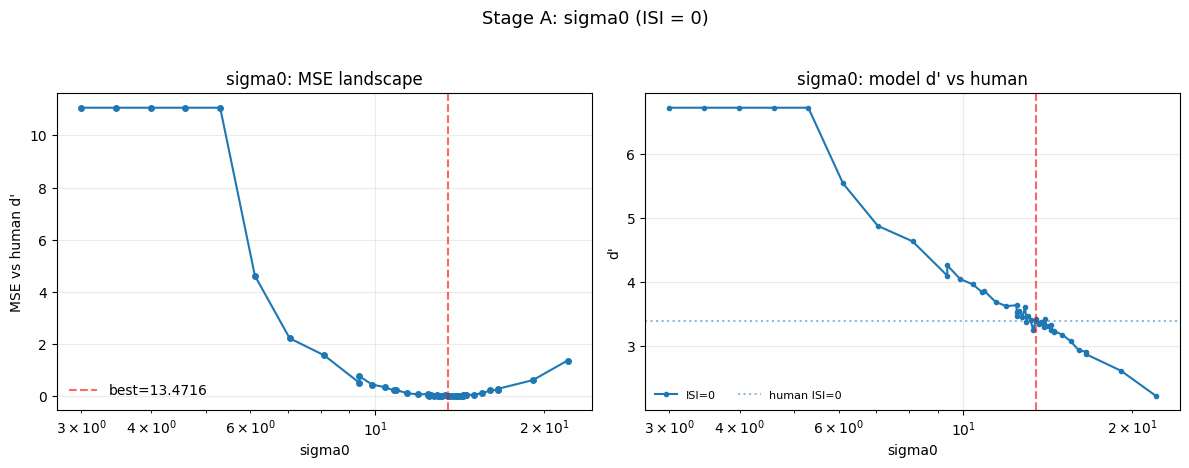

In [7]:
isi0_exps = {
    0: make_toy_experiment_list(
        stimulus_pool, isi=0, n_experiments=20, k_stimuli=5, seed=0
    )
}
print(f"ISI-0 toy experiments: {len(isi0_exps[0])} exps, "
      f"avg len {np.mean([len(e) for e in isi0_exps[0]]):.0f} trials")

N_REFINE_ITERS = 3
N_MC = 32

stage_a = fit_sigma_1d(
    run_experiment_fn=run_experiment_scores,
    sigma_name="sigma0",
    sigma_bounds=param_bounds["sigma0"],
    fixed_sigmas={"sigma1": sigma1_init, "sigma2": sigma2_init},
    noise_mode=noise_mode,
    metric=metric,
    X0=X,
    name_to_idx=name_to_idx,
    experiments_by_isi=isi0_exps,
    human_dprimes_by_isi=sigma0_human,
    t_step=t_step,
    n_grid=15,
    n_mc=N_MC,
    n_refine_iters=N_REFINE_ITERS,
    seed=0,
)

sigma0_fitted = stage_a["best_sigma"]
print(f"\n>>> sigma0 = {sigma0_fitted:.6f}  (MSE = {stage_a['best_mse']:.6f})")
plot_sigma_fit(stage_a, human_dprimes_by_isi=sigma0_human,
               title="Stage A: sigma0 (ISI = 0)");

---
## Stage B: Fit sigma1 (ISIs [1, 2, 4], compact sequences)

Generate compact multi-ISI sequences that interleave repeat pairs at
ISIs 1, 2, and 4 within each short sequence.  With sigma0 fixed from
Stage A, sigma1 is the only free parameter in this regime.

In [33]:
SIGMA1_ISIS     = [1, 2, 4]
SIGMA1_LENGTH   = 60     # divisible by 3; 60//3=20 pair slots >= 3*5=15 ISI pairs
SIGMA1_N_SEQS   = 32
SIGMA1_MIN_PAIRS = 5

sigma1_exps, sigma1_isi_keys = make_compact_multi_isi_sequences(
    stimulus_pool=stimulus_pool,
    isi_values=SIGMA1_ISIS,
    n_sequences=SIGMA1_N_SEQS,
    length=SIGMA1_LENGTH,
    min_pairs_per_isi=SIGMA1_MIN_PAIRS,
    seed=1000,
)

print(f"Generated {len(sigma1_exps)} compact sequences")
print(f"Trials per sequence: {len(sigma1_exps[0])}")

# Validate ISI distribution
from collections import defaultdict
sigma1_isi_counts = defaultdict(list)
for seq in sigma1_exps:
    counts = Counter(infer_trial_isis(seq))
    for isi_val in SIGMA1_ISIS:
        sigma1_isi_counts[isi_val].append(counts.get(isi_val, 0))

print("\nPairs per ISI per sequence (mean +/- std):")
for isi_val in SIGMA1_ISIS:
    vals = sigma1_isi_counts[isi_val]
    print(f"  ISI {isi_val}: {np.mean(vals):.1f} +/- {np.std(vals):.1f}  "
          f"(min={min(vals)}, max={max(vals)})")

Aggregate ISI usage across all sequences:
  ISI -1: 400
  ISI 1: 236
  ISI 2: 226
  ISI 4: 338
Generated 10 compact sequences
Trials per sequence: 120

Pairs per ISI per sequence (mean +/- std):
  ISI 1: 11.8 +/- 5.7  (min=8, max=23)
  ISI 2: 11.3 +/- 1.6  (min=9, max=14)
  ISI 4: 16.9 +/- 5.9  (min=8, max=23)


In [35]:
stage_b = fit_sigma_1d(
    run_experiment_fn=run_experiment_scores,
    sigma_name="sigma1",
    sigma_bounds=param_bounds["sigma1"],
    fixed_sigmas={"sigma0": sigma0_fitted, "sigma2": sigma2_init},
    noise_mode=noise_mode,
    metric=metric,
    X0=X,
    name_to_idx=name_to_idx,
    human_dprimes_by_isi=sigma1_human,
    t_step=t_step,
    n_grid=5,
    n_mc=N_MC,
    n_refine_iters=N_REFINE_ITERS,
    seed=100_000,
    # compact mode
    experiment_list=sigma1_exps,
    isi_keys=sigma1_isi_keys,
    target_isis=SIGMA1_ISIS,
    n_seqs_per_rep=SIGMA1_N_SEQS//2,
)

sigma1_fitted = stage_b["best_sigma"]
print(f"\n>>> sigma1 = {sigma1_fitted:.6f}  (MSE = {stage_b['best_mse']:.6f})")
plot_sigma_fit(stage_b, human_dprimes_by_isi=sigma1_human,
               title="Stage B: sigma1 (ISIs [1, 2, 4], compact)");


--- sigma1 iteration 1/3 ---
  Bounds: (0.100000, 10.000000), 5 candidates


Fitting sigma1 (iter 1):   0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 

---
## Stage C: Fit sigma2 (ISIs [8, 16, 32, 64], compact sequences)

Compact sequences are especially advantageous here: per-ISI toy
experiments need ~130 trials each for ISI=64, while compact sequences
cover all four ISIs in ~75 trials.

In [44]:
SIGMA2_ISIS      = [8, 16, 32, 64]
SIGMA2_LENGTH    = 75    # divisible by 3, >= max(64) + 2 = 66
SIGMA2_N_SEQS    = 32
SIGMA2_MIN_PAIRS = 5

sigma2_exps, sigma2_isi_keys = make_compact_multi_isi_sequences(
    stimulus_pool=stimulus_pool,
    isi_values=SIGMA2_ISIS,
    n_sequences=SIGMA2_N_SEQS,
    length=SIGMA2_LENGTH,
    min_pairs_per_isi=SIGMA2_MIN_PAIRS,
    seed=2000,
)

print(f"Generated {len(sigma2_exps)} compact sequences")
print(f"Trials per sequence: {len(sigma2_exps[0])}")

# Validate ISI distribution
sigma2_isi_counts = defaultdict(list)
for seq in sigma2_exps:
    counts = Counter(infer_trial_isis(seq))
    for isi_val in SIGMA2_ISIS:
        sigma2_isi_counts[isi_val].append(counts.get(isi_val, 0))

print("\nPairs per ISI per sequence (mean +/- std):")
for isi_val in SIGMA2_ISIS:
    vals = sigma2_isi_counts[isi_val]
    print(f"  ISI {isi_val:>2}: {np.mean(vals):.1f} +/- {np.std(vals):.1f}  "
          f"(min={min(vals)}, max={max(vals)})")

Aggregate ISI usage across all sequences:
  ISI -1: 400
  ISI 8: 188
  ISI 16: 200
  ISI 32: 226
  ISI 64: 186
Generated 10 compact sequences
Trials per sequence: 120

Pairs per ISI per sequence (mean +/- std):
  ISI  8: 9.4 +/- 0.7  (min=9, max=11)
  ISI 16: 10.0 +/- 0.8  (min=9, max=11)
  ISI 32: 11.3 +/- 0.9  (min=10, max=13)
  ISI 64: 9.3 +/- 0.6  (min=9, max=11)


In [45]:
stage_c = fit_sigma_1d(
    run_experiment_fn=run_experiment_scores,
    sigma_name="sigma2",
    sigma_bounds=param_bounds["sigma2"],
    fixed_sigmas={"sigma0": sigma0_fitted, "sigma1": sigma1_fitted},
    noise_mode=noise_mode,
    metric=metric,
    X0=X,
    name_to_idx=name_to_idx,
    human_dprimes_by_isi=sigma2_human,
    t_step=t_step,
    n_grid=5,
    n_mc=N_MC,
    n_refine_iters=N_REFINE_ITERS,
    seed=200_000,
    # compact mode
    experiment_list=sigma2_exps,
    isi_keys=sigma2_isi_keys,
    target_isis=SIGMA2_ISIS,
    n_seqs_per_rep=SIGMA2_N_SEQS//2,
)

sigma2_fitted = stage_c["best_sigma"]
print(f"\n>>> sigma2 = {sigma2_fitted:.6f}  (MSE = {stage_c['best_mse']:.6f})")
plot_sigma_fit(stage_c, human_dprimes_by_isi=sigma2_human,
               title="Stage C: sigma2 (ISIs [8, 16, 32, 64], compact)");


--- sigma2 iteration 1/3 ---
  Bounds: (0.000500, 1.000000), 5 candidates


Fitting sigma2 (iter 1):   0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 

---
## 5. Fitted parameter summary

In [55]:
print("=" * 50)
print("THREE-STAGE FIT (compact sequences)")
print("=" * 50)
print(f"  sigma0 = {sigma0_fitted:.6f}  (Stage A MSE: {stage_a['best_mse']:.6f})")
print(f"  sigma1 = {sigma1_fitted:.6f}  (Stage B MSE: {stage_b['best_mse']:.6f})")
print(f"  sigma2 = {sigma2_fitted:.6f}  (Stage C MSE: {stage_c['best_mse']:.6f})")

THREE-STAGE FIT (compact sequences)
  sigma0 = 13.503581  (Stage A MSE: 0.000077)


NameError: name 'sigma1_fitted' is not defined

---
## 6. Final evaluation on ALL real sequences

Evaluate the fitted parameters on every real participant sequence across
all ISI conditions [0, 1, 2, 4, 8, 16, 32, 64].

In [ ]:
%%time
import numpy as np

# -----------------------------
# seed params (from your fit)
# -----------------------------
sigma0_center = sigma0_fitted
sigma1_center = sigma1_fitted
sigma2_center = sigma2_fitted

# -----------------------------
# iterative local search config
# -----------------------------
n_rounds = 3
n_samples_per_round = 10*n_rounds
num_exps = len(human_runs)//n_rounds
epsilon_start = 0.30
epsilon_shrink = 0.9   # round2 epsilon = round1 * 0.60
base_seed = 42

assert num_exps <= len(human_runs), "num_exps exceeds available human_runs"

best_overall = None
history = []

for r in range(n_rounds):
    eps = epsilon_start * (epsilon_shrink ** r)
    bot_p, top_p = 1.0 - eps, 1.0 + eps

    # random subset of human runs (NOT first n)
    rng_subset = np.random.default_rng(base_seed + 10_000 + r)
    subset_idx = rng_subset.choice(len(human_runs), size=num_exps, replace=False)
    subset_runs = [human_runs[i] for i in subset_idx]
    human_curve_part = compute_human_curve(subset_runs, is_multi, which_isi)

    # search around current centers
    final_pb = {
        "sigma0": (sigma0_center * bot_p, sigma0_center * top_p),
        "sigma1": (sigma1_center * bot_p, sigma1_center * top_p),
        "sigma2": (sigma2_center, sigma2_center),  # fixed typo from prior cell
        "t_step": (t_step, t_step),
    }

    final_results = random_search_gridlike(
        n_samples=n_samples_per_round,
        param_bounds=final_pb,
        noise_mode=noise_mode,
        metric=metric,
        X0=X,
        name_to_idx=name_to_idx,
        experiment_list=exp_list,
        isis=isis,
        human_curve=human_curve_part,
        layer=encoder_name,
        encoder_name=encoder_name,
        hr_task_name=hr_task_name,
        subsample=len(subset_runs),
        random_draw=False,
        seed=base_seed + r,
    )

    # pick best iteration by mean MSE across ISIs
    def mean_mse(rec):
        mse = np.asarray(rec["mse_per_isi"], dtype=float)
        return float(np.nanmean(mse))

    best_idx = int(np.nanargmin([mean_mse(rec) for rec in final_results]))
    best_round = final_results[best_idx]
    best_round_mse = mean_mse(best_round)

    p = best_round["params"]
    sigma0_center = float(p["sigma0"])
    sigma1_center = float(p["sigma1"])
    sigma2_center = float(p["sigma2"])

    history.append({
        "round": r + 1,
        "epsilon": eps,
        "best_idx": best_idx,
        "best_mean_mse": best_round_mse,
        "best_params": (sigma0_center, sigma1_center, sigma2_center),
    })

    if (best_overall is None) or (best_round_mse < best_overall["best_mean_mse"]):
        best_overall = history[-1]

    print(f"\nRound {r+1}/{n_rounds}")
    print(f"  epsilon: {eps:.4f}")
    print(f"  chosen subset size: {len(subset_runs)}")
    print(f"  best sample idx: {best_idx}")
    print(f"  best mean MSE: {best_round_mse:.6f}")
    print(f"  best params: sigma0={sigma0_center:.4f}, sigma1={sigma1_center:.4f}, sigma2={sigma2_center:.4f}")
    print(f"  best MSE per ISI: {best_round['mse_per_isi']}")
    print(f"  best MSE (ISI=0): {best_round['mse_per_isi'][0]:.6f}")
    print(f"  best MSE (ISI>=1): {np.mean(best_round['mse_per_isi'][1:]):.6f}")

print("\n" + "=" * 60)
print("Best overall across rounds:")
print(best_overall)
print("=" * 60)


In [ ]:
best_fits = generate_and_plot_model_decay_summary_v5(
    [best_overall],
    human_curve_part,
    isis,
    metric_name="mse_per_isi",
    isi_indices=list(range(len(isis))),
    savedir=None,
    max_rows=1,
    hr_task_name=hr_task_name,
    encoder_name=encoder_name,
)

## 7. Summary plot: model vs human d' across all ISIs

In [ ]:
# best_fits = generate_and_plot_model_decay_summary_v5(
#     final_results,
#     human_curve_full,
#     isis,
#     metric_name="mse_per_isi",
#     isi_indices=list(range(len(isis))),
#     savedir=None,
#     max_rows=1,
#     hr_task_name=hr_task_name,
#     encoder_name=encoder_name,
# )

Generated 32 compact sequences
Trials per sequence: 75

Pairs per ISI per sequence (mean +/- std):
  ISI  8: 6.0 +/- 0.8  (min=5, max=8)
  ISI 16: 6.6 +/- 1.5  (min=5, max=10)
  ISI 32: 7.4 +/- 1.6  (min=5, max=10)
  ISI 64: 5.0 +/- 0.2  (min=5, max=6)
